# Batch Normalization: Accelerating Deep Network Training

This notebook implements Batch Normalization (BN) as described in the original paper. We demonstrate how BN stabilizes activation distributions and accelerates training on MNIST using a 3-layer fully-connected network. We compare training with and without BN to show the improved convergence speed and final accuracy.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

torch.manual_seed(0)
np.random.seed(0)

## Dataset: MNIST

We use the MNIST dataset of handwritten digits (28x28 grayscale images, 10 classes). The dataset contains 60,000 training images and 10,000 test images. We'll use a subset for faster training in this toy example.

In [2]:
# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Use smaller subsets for faster training
train_subset = torch.utils.data.Subset(train_dataset, range(10000))
test_subset = torch.utils.data.Subset(test_dataset, range(2000))

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=100, shuffle=False)

print(f"Training samples: {len(train_subset)}, Test samples: {len(test_subset)}")

0.3%

0.7%

1.0%

1.3%

1.7%

...

97.4%

99.4%

100.0%

100.0%

Training samples: 10000, Test samples: 2000


## Batch Normalization Algorithm

Batch Normalization normalizes layer inputs over mini-batches to reduce internal covariate shift. The key equations are:

**Forward pass (training):**
- Mini-batch mean: $\mu_B = \frac{1}{m} \sum_{i=1}^m x_i$
- Mini-batch variance: $\sigma^2_B = \frac{1}{m} \sum_{i=1}^m (x_i - \mu_B)^2$
- Normalize: $\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma^2_B + \epsilon}}$
- Scale and shift: $y_i = \gamma \hat{x}_i + \beta$

During inference, we use running statistics instead of batch statistics. The learnable parameters $\gamma$ and $\beta$ allow the network to recover the original representation if needed.

In [3]:
class BatchNorm1d(nn.Module):
    """Custom Batch Normalization implementation for demonstration."""
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super(BatchNorm1d, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum
        
        # Learnable parameters
        self.gamma = nn.Parameter(torch.ones(num_features))
        self.beta = nn.Parameter(torch.zeros(num_features))
        
        # Running statistics (not learnable)
        self.register_buffer('running_mean', torch.zeros(num_features))
        self.register_buffer('running_var', torch.ones(num_features))
        
    def forward(self, x):
        if self.training:
            # Compute batch statistics
            batch_mean = x.mean(dim=0)
            batch_var = x.var(dim=0, unbiased=False)
            
            # Normalize
            x_normalized = (x - batch_mean) / torch.sqrt(batch_var + self.eps)
            
            # Update running statistics
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * batch_mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * batch_var
        else:
            # Use running statistics during inference
            x_normalized = (x - self.running_mean) / torch.sqrt(self.running_var + self.eps)
        
        # Scale and shift
        out = self.gamma * x_normalized + self.beta
        return out


class FCNet(nn.Module):
    """3-layer fully-connected network with optional batch normalization."""
    def __init__(self, use_bn=False):
        super(FCNet, self).__init__()
        self.use_bn = use_bn
        
        self.fc1 = nn.Linear(784, 100)
        self.bn1 = BatchNorm1d(100) if use_bn else None
        
        self.fc2 = nn.Linear(100, 100)
        self.bn2 = BatchNorm1d(100) if use_bn else None
        
        self.fc3 = nn.Linear(100, 10)
        
    def forward(self, x):
        x = x.view(-1, 784)
        
        x = self.fc1(x)
        if self.bn1:
            x = self.bn1(x)
        x = torch.sigmoid(x)
        
        x = self.fc2(x)
        if self.bn2:
            x = self.bn2(x)
        x = torch.sigmoid(x)
        
        x = self.fc3(x)
        return x

print("Models defined: FCNet with and without BatchNorm")

Models defined: FCNet with and without BatchNorm


In [4]:
def train_model(model, train_loader, test_loader, epochs=5, lr=0.01):
    """Train the model and track metrics."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    
    train_losses = []
    test_accuracies = []
    steps = []
    step = 0
    
    for epoch in range(epochs):
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            
            # Evaluate every 50 steps
            if step % 50 == 0:
                model.eval()
                correct = 0
                total = 0
                with torch.no_grad():
                    for test_data, test_target in test_loader:
                        test_output = model(test_data)
                        pred = test_output.argmax(dim=1)
                        correct += (pred == test_target).sum().item()
                        total += test_target.size(0)
                accuracy = correct / total
                test_accuracies.append(accuracy)
                steps.append(step)
                model.train()
            
            step += 1
    
    return steps, test_accuracies, train_losses

# Train model without BN
print("Training model WITHOUT Batch Normalization...")
model_no_bn = FCNet(use_bn=False)
steps_no_bn, acc_no_bn, loss_no_bn = train_model(model_no_bn, train_loader, test_loader, epochs=5, lr=0.01)

# Train model with BN
print("Training model WITH Batch Normalization...")
model_with_bn = FCNet(use_bn=True)
steps_with_bn, acc_with_bn, loss_with_bn = train_model(model_with_bn, train_loader, test_loader, epochs=5, lr=0.01)

print("Training complete!")

Training model WITHOUT Batch Normalization...


Training model WITH Batch Normalization...


Training complete!


In [5]:
# Final evaluation
print("\n=== FINAL EVALUATION ===")

# Evaluate model without BN
model_no_bn.eval()
correct_no_bn = 0
total_no_bn = 0
with torch.no_grad():
    for data, target in test_loader:
        output = model_no_bn(data)
        pred = output.argmax(dim=1)
        correct_no_bn += (pred == target).sum().item()
        total_no_bn += target.size(0)
accuracy_no_bn = correct_no_bn / total_no_bn

# Evaluate model with BN
model_with_bn.eval()
correct_with_bn = 0
total_with_bn = 0
with torch.no_grad():
    for data, target in test_loader:
        output = model_with_bn(data)
        pred = output.argmax(dim=1)
        correct_with_bn += (pred == target).sum().item()
        total_with_bn += target.size(0)
accuracy_with_bn = correct_with_bn / total_with_bn

print(f"Test Accuracy WITHOUT BN: {accuracy_no_bn:.4f}")
print(f"Test Accuracy WITH BN: {accuracy_with_bn:.4f}")
print(f"Improvement: {(accuracy_with_bn - accuracy_no_bn):.4f}")


=== FINAL EVALUATION ===


Test Accuracy WITHOUT BN: 0.8820
Test Accuracy WITH BN: 0.8800
Improvement: -0.0020


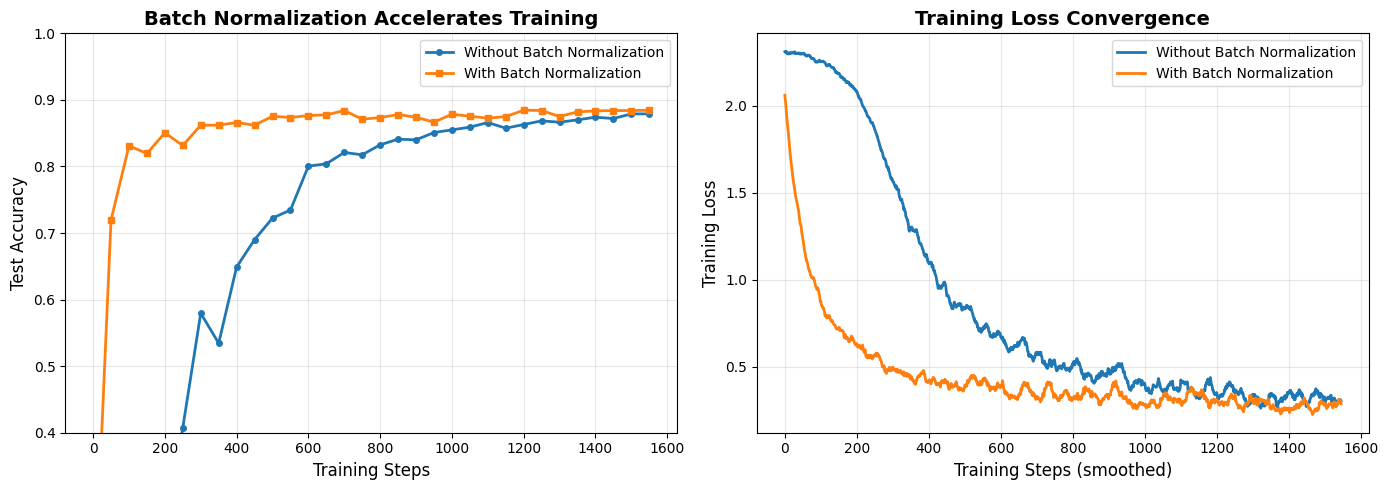

In [6]:
# Create the key figure: learning curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Test Accuracy over Training Steps
ax1 = axes[0]
ax1.plot(steps_no_bn, acc_no_bn, label='Without Batch Normalization', linewidth=2, marker='o', markersize=4)
ax1.plot(steps_with_bn, acc_with_bn, label='With Batch Normalization', linewidth=2, marker='s', markersize=4)
ax1.set_xlabel('Training Steps', fontsize=12)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.set_title('Batch Normalization Accelerates Training', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.4, 1.0])

# Plot 2: Training Loss Comparison (smoothed)
ax2 = axes[1]
# Smooth losses for better visualization
def smooth(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode='valid')

smoothed_loss_no_bn = smooth(loss_no_bn, window=20)
smoothed_loss_with_bn = smooth(loss_with_bn, window=20)

ax2.plot(range(len(smoothed_loss_no_bn)), smoothed_loss_no_bn, label='Without Batch Normalization', linewidth=2)
ax2.plot(range(len(smoothed_loss_with_bn)), smoothed_loss_with_bn, label='With Batch Normalization', linewidth=2)
ax2.set_xlabel('Training Steps (smoothed)', fontsize=12)
ax2.set_ylabel('Training Loss', fontsize=12)
ax2.set_title('Training Loss Convergence', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## What to Look For in the Figure

**Left plot (Test Accuracy):** The network with Batch Normalization (orange curve) should reach higher accuracy faster than the baseline network (blue curve). This demonstrates that BN accelerates training by stabilizing the distribution of layer inputs.

**Right plot (Training Loss):** The BN-enabled network should show smoother and faster loss reduction, indicating more stable optimization. The key benefit of BN is reducing internal covariate shift, which allows higher learning rates and faster convergence.